# Probabilistic/Monte Carlo Model

This model predicts a **distribution** of fatigue lives instead of one value.

- many random defects are generated
- a distribution (normal/lognormal/etc.) is sampled from 
- the critical defect is selected
- fatigue life is computed repeatedly

So every simulation gives a different fatigue life.

Outputs:

- histograms of fatigue life
- reliability curves
- probability of failure
- Weibull-type behavior
- maximum defect statistics
- scatter in S–N behavior

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.stats import weibull_min

# Variables

In [2]:
# C, material const., calibrated experimentally
# set values to calibrate C
stress_amp = 100        # stress amplitude
defect_size = 100       # defect size
N_target = 1e5          # target N for these values        
m = 2.7                 # sensitivity to stress
n = 1.5                 # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))

# calibrate C given these values
C = N_target * (stress_amp**m) * (defect_size**n)

In [3]:
# define constants
mu = 3              # mean of log
sigma = 1           # std dev of log
Y = 1.0             # geometry factor

# define variables
n_defects = 1000    # size of random dataset
defect_size = np.linspace(start=20, stop=600, num=n_defects)     # surface area of defect, A, [mm^2]
stress_amp = np.linspace(start=50, stop=500, num=n_defects)      # stress amplitude [MPa]

# Functions

## Data

Defect data is generated randomly based on lognormal distribution.

In [4]:
# define function to generate defects based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # no. of random samples generated

# generate n_defects random defects
defects = generate_defects(n_defects, mu, sigma)

### Histogram

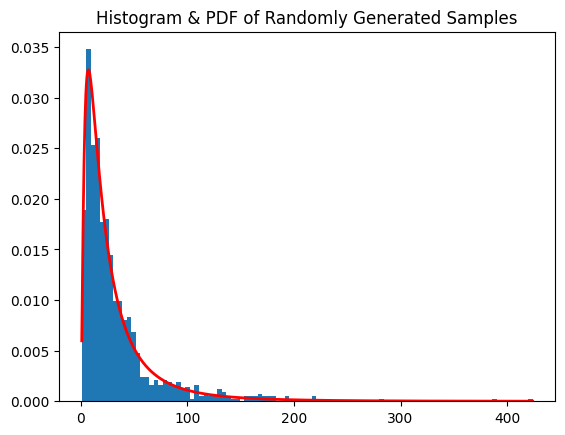

In [ ]:
# show histogram and probability density function of randomly generated samples
count, bins, ignored = plt.hist(defects,
                                bins=100,
                                density=True,
                                align='mid')

x = np.linspace(min(bins), max(bins), n_defects)
pdf = (np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
       /(x*sigma*np.sqrt(2*np.pi)))


# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')

plt.plot(x, pdf, linewidth=2, color='r')
plt.axis('tight')
plt.show()

### Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

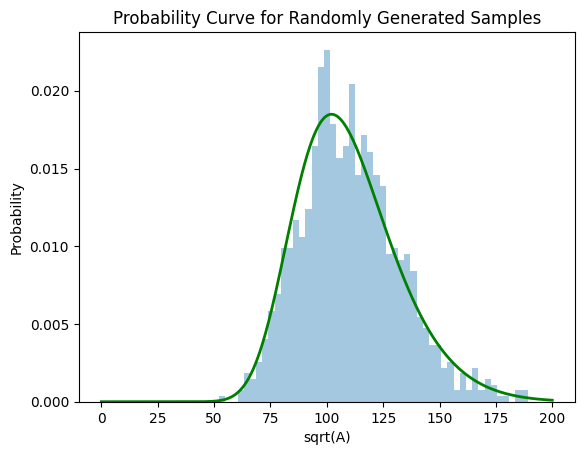

In [6]:
# generate random extreme values
samples = genextreme.rvs(c=0.1,             # shape parameter
                         loc=100,           # center/location
                         scale=20,          # spread
                         size=n_defects)

# calculate pdf
x2 = np.linspace(0, 200, n_defects)
pdf2 = genextreme.pdf(x2, c=0.1, loc=100, scale=20)

# add histogram
plt.hist(samples, bins=50, density=True, alpha=0.4)

# axis labels
plt.title('Probability Curve for Randomly Generated Samples')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x2, pdf2, linewidth=2, color='g')
plt.axis('tight')
plt.show()

## Critical Defects
The critical defect is the one that leads to failure. Assume this is the largest defect.

The critical (max) defect is found.

In [ ]:
# define function to select the crtical defect
def critical_defect(defects):
    # defect that dominates fatigue failure = max defect
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print("The critical (max) defect size is",A_crit)

The critical (max) defect size is 423.88599051377264


## Fatigue Life

Fatigue life or the number of cycles, N, is determined based on,

**N = C / (stress_amp^m * A^n)**

In [ ]:
# define function to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## Shiozawa Model

The stress intensity factor, delta(K), the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [9]:
# define function to compute stress intensity factor, delta(K)
def stress_intensity_factor(stress_amp, defect_size):
    return Y * stress_amp * np.sqrt(np.pi * defect_size)

# Monte Carlo Loop

simulate randomness many times

Each specimen has random defects. So:
- n_defects number of virtual specimens is generated
- each specimen gets random defects
- the critical defect is calculated for each
- the distribution of fatigue lives is predicted
- the life distribution is observed

## Fixed Stress

In [10]:
# set fixed stress amplitude, S, [MPa]
S_fixed = 250

# list to store results
lives = []          # list to store fatigue lives
M = []              # list to store Murakami parameter
max_defects = []    # list to store max defects
K = []              # list to store stress intensity factors
N_norm = []         # list to store normalized fatigue lives

for i in range(1000):
    defects = generate_defects(n_defects, mu, sigma)
    
    A_crit = critical_defect(defects)
    N = fatigue_life(S_fixed, A_crit, C, m, n)
    Murakami = np.sqrt(A_crit)              # Murakami parameter for defect size, sqrt(A)
    delta_K = stress_intensity_factor(S_fixed, A_crit)
    N_normal = N / Murakami                 # calculate normalized fatigue life, N/sqrt(A)
    
    # store results in lists
    lives.append(N)
    M.append(Murakami)
    max_defects.append(np.max(defects))
    K.append(delta_K)
    N_norm.append(N_normal)
    

### Fatigue Life

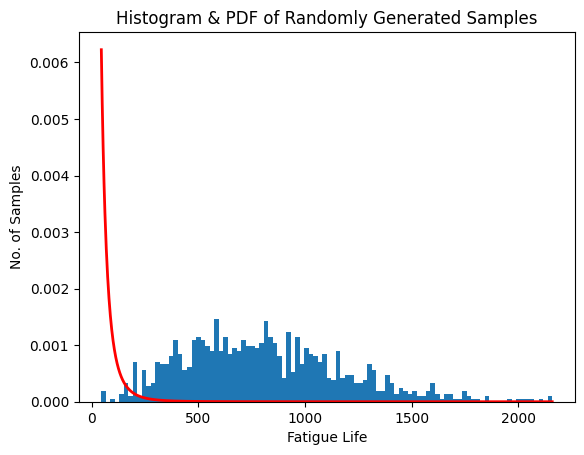

In [11]:
# plot fatigue life histogram
count, bins, ignored = plt.hist(lives,
                                bins=100,
                                density=True,
                                align='mid')

x1 = np.linspace(min(bins), max(bins), n_defects)
pdf1 = (np.exp(-(np.log(x1)-mu)**2/(2*sigma**2))
       /(x1*sigma*np.sqrt(2*np.pi)))

# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')
plt.xlabel('Fatigue Life')
plt.ylabel('No. of Samples')

plt.plot(x1, pdf1, linewidth=2, color='r')
plt.axis('tight')
plt.show()

In [12]:
# mean fatigue life
N_avg = np.mean(lives)

# std dev of faigue life
N_sigma = np.std(lives)

print("The average fatigue life is", N_avg)
print("The standard deviation of the fatigue life is", N_sigma)

The average fatigue life is 809.0061982580603
The standard deviation of the fatigue life is 375.61782402081434


### GEV, P vs sqrt(A)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

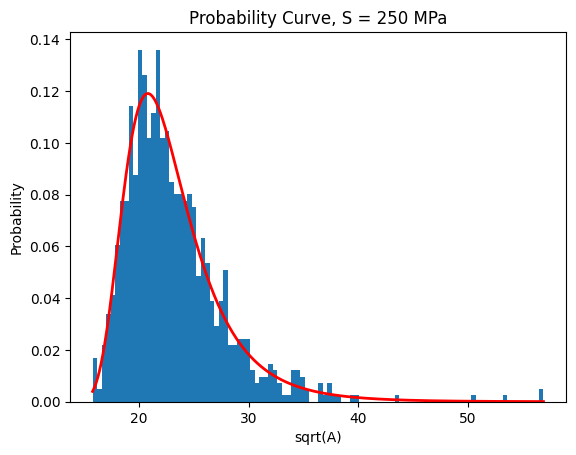

In [ ]:
# failure probability, P vs sqrt(defect_size)
c, loc, scale = genextreme.fit(M)

# show histogram and probability density function
count, bins, ignored = plt.hist(M,
                                bins=100,
                                density=True,
                                align='mid')

# calculate pdf
x3 = np.linspace(min(M), max(M), n_defects)
pdf3 = genextreme.pdf(x3, c, loc, scale)

# axis labels
plt.title('Probability Curve, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x3, pdf3, linewidth=2, color='r')
plt.axis('tight')
plt.show()

### Shiozawa Curves

Shiozawa: stress intensity factor, delta(K), at the critical defect vs. sqrt(A)

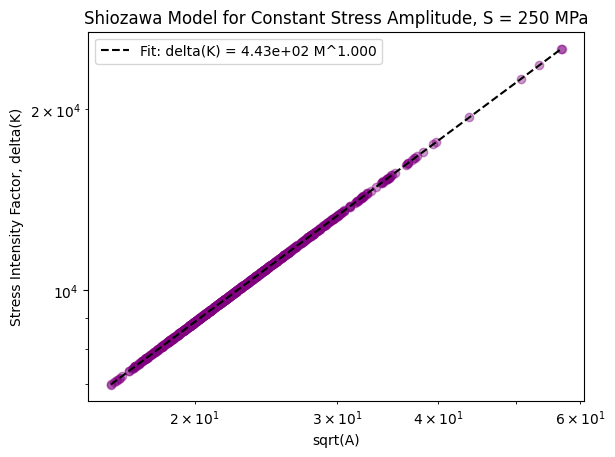

In [14]:
# log transform
logM = np.log10(M)
logK = np.log10(K)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(logM, logK, 1)
a = 10**loga

# fitted curve
M_line = np.logspace(np.log10(min(M)), np.log10(max(M)), 200)
K_line = a * M_line**b

# scatter plot of delta(K) vs sqrt(A)
plt.scatter(M, K, alpha=0.4, color='purple')

# plot fit
plt.plot(M_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

Under constant stress, as the size of the defect increases, the stress intensity factor increases exponentially since both x and y, delta(K) and sqrt(A), respectively, are log-transformed.

#### Confidence Intervals

In [15]:
logM = np.log10(M)

# create bins for logM
bins = np.linspace(min(logM), max(logM), 20)

# calculate mean and std dev of stress values in each bin
K_avg = []
K_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logM >= bins[i]) & (logM < bins[i+1])
    Ks_in_bin = np.array(K)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    K_avg.append(np.mean(Ks_in_bin))
    K_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins[i] + bins[i+1]))

K_avg = np.array(K_avg)
K_std = np.array(K_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = K_avg + 1.96 * K_std
lower_K = K_avg - 1.96 * K_std

upper = np.array(upper_K)
lower = np.array(lower_K)

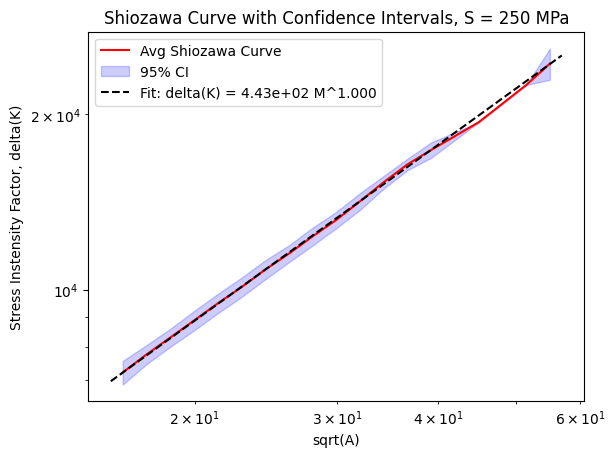

In [16]:
xvals1 = np.power(10, centers)

plt.plot(xvals1, K_avg, 'red', label='Avg Shiozawa Curve')

plt.fill_between(xvals1, lower_K, upper_K,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

# plot fit
plt.plot(M_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Curve with Confidence Intervals, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Instensity Factor, delta(K)')

plt.legend()
plt.show()

The narrow confidence intervals imply a good certainty in the estimate.

### Reliability Curves
the probability a specimen survives beyond a given 

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [17]:
# sort fatigue lives
lives_sorted = np.sort(np.array(lives))

# calculate survival probability
j = len(lives_sorted)
R = 1 - np.arange(j) / j

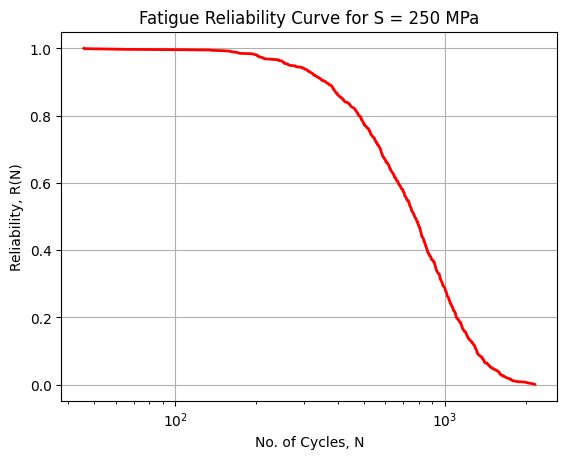

In [18]:
# plot reliability curve
plt.plot(lives_sorted, R,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

At low cycle counts, near one, almost nothing has failed yet. Then the curve drops: at around 50%, reliability has decreased and about half have failed. Finally, reliability approaches zero, so around 1100 cycles, almost all specimens have failed.

#### Weibull Reliability Model
This is more of a **statistical reliability model** rather than a crack-growth physics model.

Instead of simulating defects directly, failure probability is modeled with a Weibull distribution.

Typically, **R(N) = exp[-(N/η)^β]**

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

This model describes how failure probability evolves with cycles.

In [19]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals = np.linspace(min(lives), max(lives), 200)
R_theory = np.exp(-(N_vals / scale)**shape)

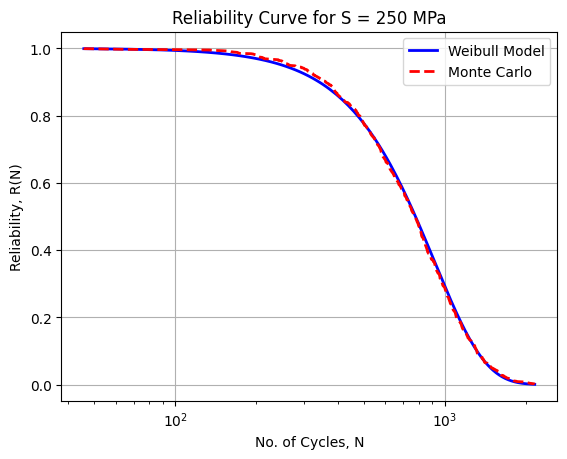

In [20]:
# plot theoretical reliability curve
plt.plot(N_vals, R_theory,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted = np.sort(lives)
R_emp = 1 - np.arange(len(lives)) / len(lives)

plt.plot(lives_sorted, R_emp,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are very close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior well.

### Normalized Life
plot **delta(K_i) vs N/sqrt(A)**
where N/sqrt(A) = defect-normalized life

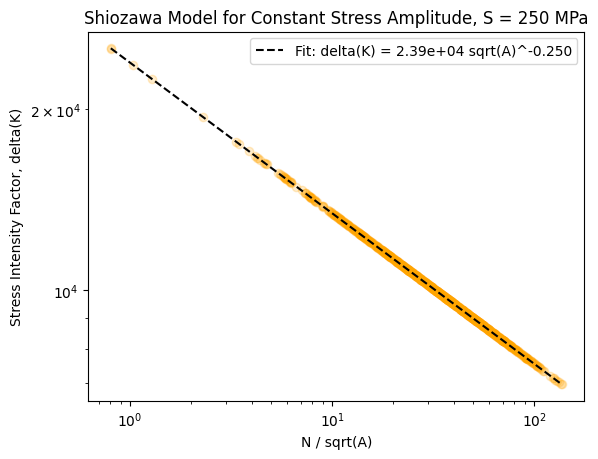

In [21]:
# log transform
logN_norm = np.log10(N_norm)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(logN_norm, logK, 1)
a = 10**loga

# fitted curve
N_norm_line = np.logspace(np.log10(min(N_norm)), np.log10(max(N_norm)), 200)
K_line = a * N_norm_line**b

# scatter plot of delta(K) vs N/sqrt(A)
plt.scatter(N_norm, K, alpha=0.2, color='orange')

# plot fit
plt.plot(N_norm_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} sqrt(A)^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('N / sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

## Varying Sress

### Shiozawa Curve
with normalized life plot **delta(K_i) vs N/sqrt(A)** where N/sqrt(A) = defect-normalized life

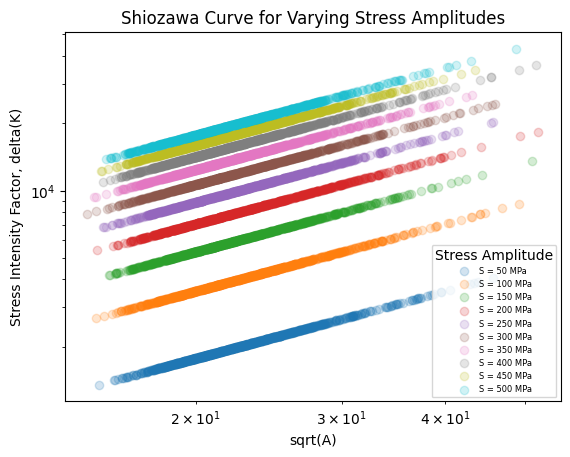

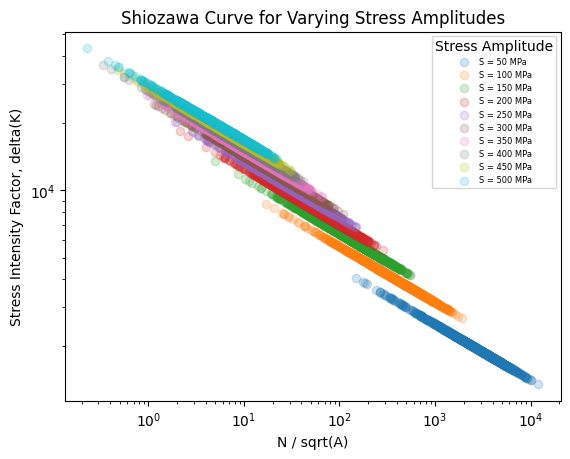

In [22]:
# vary stress amplitude, S
S_vals = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

for S_i in S_vals:

    # temporary lists for this stress amplitude
    M_temp = []
    K_temp = []
    N_norm_temp = []

    lives_temp = []
    max_defects_temp = []

    for i in range(1000):
        defects = generate_defects(n_defects, mu, sigma)

        A_crit1 = critical_defect(defects)
        Murakami1 = np.sqrt(A_crit1)
        delta_K1 = stress_intensity_factor(S_i, A_crit1)
        N1 = fatigue_life(S_i, A_crit1, C, m, n)
        N_normal1 = N1 / Murakami1

        # store points for this stress amplitude
        M_temp.append(Murakami1)
        K_temp.append(delta_K1)
        N_norm_temp.append(N_normal1)

        lives_temp.append(N1)
        max_defects_temp.append(np.max(defects))
        
    # plot 1: delta(K) vs sqrt(A), for all points at this stress amplitude
    plt.figure(1)
    plt.scatter(M_temp, K_temp, alpha=0.2, label=f'S = {S_i} MPa')

    # plot 2: delta(K) vs N/sqrt(A) for this stress amplitude
    plt.figure(2)
    plt.scatter(N_norm_temp, K_temp, alpha=0.2, label=f'S = {S_i} MPa')

# figure 1: delta(K) vs sqrt(A)
plt.figure(1)

plt.xscale('log')
plt.yscale('log')

# figure 1: axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')

# log scales
plt.xscale('log')
plt.yscale('log')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')

# figure 2: delta(K) vs N/sqrt(A)
plt.figure(2)

plt.xscale('log')
plt.yscale('log')

# figure 2: axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('N / sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend(title='Stress Amplitude', fontsize=6, loc='upper right')

plt.show()

A higher stress amplitude results in a higher stress intensity factor.
The stress intensity factor and Murakami factor are related exponentially since both axes are log-transformed.

### Reliability Curves
the probability a specimen survives beyond a given life

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [23]:
# sort fatigue lives
lives_sorted1 = np.sort(np.array(lives_temp))

# calculate survival probability
j1 = len(lives_sorted1)
R1 = 1 - np.arange(j1) / j1

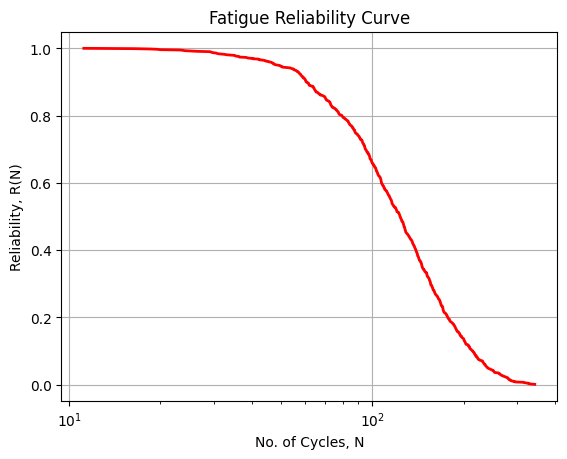

In [24]:
# plot reliability curve
plt.plot(lives_sorted1, R1,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

At low cycle counts, near 100% reliability, almost nothing has failed yet. At around 60%, reliability has decreased and almost half the specimens have failed. Finally, reliability approaches zero, so around 130 cycles, almost all specimens have failed.

#### Weibull Reliability Model
R(N) = exp[-(N/eta)^beta]

In [25]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives_temp, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals1 = np.linspace(min(lives_temp), max(lives_temp), 200)
R_theory1 = np.exp(-(N_vals1 / scale)**shape)

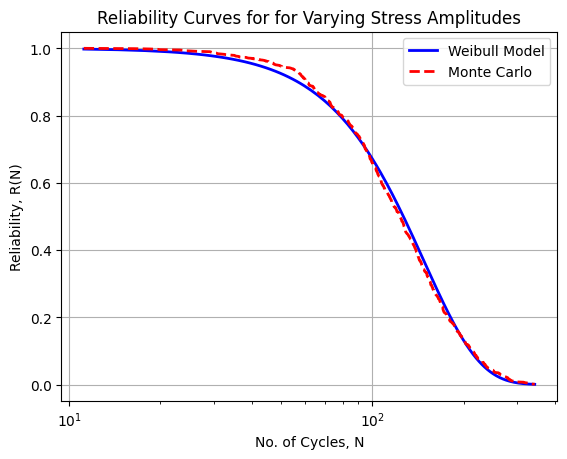

In [26]:
# plot theoretical reliability curve
plt.plot(N_vals1, R_theory1,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted1 = np.sort(lives_temp)
R_emp1 = 1 - np.arange(len(lives_temp)) / len(lives_temp)

plt.plot(lives_sorted1, R_emp1,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curves for for Varying Stress Amplitudes")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are very close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior well.